# Density-Neutron Computed Channels With pandas

This recipe uses pandas to compute porosity and gas-crossover curves from the open-hole production example.

The important shift from the YAML-first notebooks is that the data and the layout are both created from Python:

- source channels are loaded from the public example data
- derived channels are computed in the notebook and attached to a working `WellDataset`
- `LogBuilder` and `SectionBuilder` create tracks, bindings, fills, headings, and remarks
- `save_report(...)` writes the generated YAML layout artifact
- `render_report(...)` renders the in-memory report that still carries the computed channels

Important limitation: the saved YAML records the layout, but it does not persist the computed channel arrays by itself. To reproduce the computed curves, rerun the notebook or export the computed dataset with a project-specific data export step.


In [1]:
from pathlib import Path

try:
    import wellplot
except ImportError as exc:
    raise RuntimeError(
        "Install the published 'wellplot' package in the active environment "
        "before running this notebook."
    ) from exc

cwd = Path.cwd().resolve()
REPO_ROOT = next((path for path in (cwd, *cwd.parents) if (path / "examples").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError(
        "Run this notebook from a checkout of the wellplot repository so the "
        "example files and sample data are available."
    )

package_dir = REPO_ROOT / "examples" / "production" / "forge16b_porosity_example"
example_logfile = package_dir / "full_reconstruction.log.yaml"
source_section = "upper_review"
tutorial_dir = REPO_ROOT / "workspace/tutorials/computed_pandas/forge16b_porosity_example"
render_dir = tutorial_dir / "renders"
tutorial_dir.mkdir(parents=True, exist_ok=True)
render_dir.mkdir(parents=True, exist_ok=True)

print("wellplot version:", wellplot.__version__)
print("Production example:", example_logfile.relative_to(REPO_ROOT))
print("Source section:", source_section)
print("Tutorial workspace:", tutorial_dir.relative_to(REPO_ROOT))

wellplot version: 0.3.0
Production example: examples/production/forge16b_porosity_example/full_reconstruction.log.yaml
Source section: upper_review
Tutorial workspace: workspace/tutorials/computed_pandas/forge16b_porosity_example


## Inspect The Source Channels

Start by loading the same source data used by the production example and confirming the channels you will compute from.


In [2]:
from wellplot import load_datasets_for_logfile, load_logfile

spec = load_logfile(example_logfile)
datasets_by_section, source_paths_by_section = load_datasets_for_logfile(
    spec,
    base_dir=example_logfile.parent,
)
source_dataset = datasets_by_section[source_section]
source_path = source_paths_by_section[source_section]

wanted_channels = ["GR", "ILD", "ILM", "RHOB", "NPHI"]
print("Source file:", source_path.relative_to(REPO_ROOT))
print("Dataset name:", source_dataset.name)
print("Depth range, ft:", tuple(round(value, 2) for value in source_dataset.depth_range("ft")))
print("Channels used here:")
for mnemonic in wanted_channels:
    channel = source_dataset.get_channel(mnemonic)
    print(f"  {mnemonic}: {type(channel).__name__}, unit={getattr(channel, 'value_unit', None)}")

Source file: workspace/data/30-23a-3 8117_d.las
Dataset name: 30/23a-3
Depth range, ft: (336.5, 10242.5)
Channels used here:
  GR: ScalarChannel, unit=gAPI
  ILD: ScalarChannel, unit=ohmm
  ILM: ScalarChannel, unit=ohmm
  RHOB: ScalarChannel, unit=g/cc
  NPHI: ScalarChannel, unit=pu


## Compute New Channels

This cell creates derived curves and attaches them to a working dataset. In your own well, this is where your interpretation logic belongs.


In [3]:
import numpy as np
import pandas as pd

from wellplot import DatasetBuilder

rhob_channel = source_dataset.get_channel("RHOB")
depth = rhob_channel.depth
depth_unit = rhob_channel.depth_unit

frame = pd.DataFrame(
    {
        "GR": source_dataset.get_channel("GR").values,
        "ILD": source_dataset.get_channel("ILD").values,
        "ILM": source_dataset.get_channel("ILM").values,
        "RHOB": rhob_channel.values,
        "NPHI": source_dataset.get_channel("NPHI").values,
    },
    index=depth,
)
frame.index.name = "DEPTH_FT"
frame = frame.mask(frame <= -900.0)
frame["GR_SMOOTH_PD"] = frame["GR"].rolling(21, center=True, min_periods=1).mean()
frame["PHID_PD"] = ((2.65 - frame["RHOB"]) / (2.65 - 1.0) * 100.0).clip(-15.0, 60.0)
frame["ND_SEP_PD"] = (frame["NPHI"] - frame["PHID_PD"]).clip(-30.0, 30.0)
frame["RES_RATIO_PD"] = np.log10(frame["ILD"].clip(lower=0.2) / frame["ILM"].clip(lower=0.2))
frame["VSH_GR_PD"] = ((frame["GR_SMOOTH_PD"] - 35.0) / (120.0 - 35.0)).clip(0.0, 1.0)

working_dataset = (
    DatasetBuilder(name="porosity-pandas-computed")
    .merge(source_dataset, merge_well_metadata=True, merge_provenance=True)
    .add_dataframe(
        frame[["GR_SMOOTH_PD", "PHID_PD", "ND_SEP_PD", "RES_RATIO_PD", "VSH_GR_PD"]],
        use_index=True,
        index_unit=depth_unit,
        curves={
            "GR_SMOOTH_PD": {"value_unit": "gAPI", "description": "Rolling-mean gamma ray."},
            "PHID_PD": {"value_unit": "pu", "description": "Density porosity from RHOB."},
            "ND_SEP_PD": {"value_unit": "pu", "description": "NPHI minus density porosity."},
            "RES_RATIO_PD": {
                "value_unit": "log10 ratio",
                "description": "Log10 deep-to-medium resistivity ratio.",
            },
            "VSH_GR_PD": {
                "value_unit": "fraction",
                "description": "Simple gamma-ray shale index clipped to 0-1.",
            },
        },
    )
    .build()
)

computed_channels = ("GR_SMOOTH_PD", "PHID_PD", "ND_SEP_PD", "RES_RATIO_PD", "VSH_GR_PD")
print("Working dataset:", working_dataset.name)
print("Computed channels added:")
for mnemonic in computed_channels:
    series = frame[mnemonic]
    print(
        f"  {mnemonic}: min={series.min():.3g}, "
        f"p50={series.quantile(0.5):.3g}, max={series.max():.3g}"
    )

Working dataset: porosity-pandas-computed
Computed channels added:
  GR_SMOOTH_PD: min=1.23, p50=49.9, max=133
  PHID_PD: min=-15, p50=29.2, max=60
  ND_SEP_PD: min=-30, p50=15.2, max=30
  RES_RATIO_PD: min=-1.05, p50=-0.0193, max=1.74
  VSH_GR_PD: min=0, p50=0.175, max=1


## Create The YAML Layout With Builder Functions

Use `LogBuilder` and `SectionBuilder` to create the same YAML structure that a hand-written file would contain, then save it with `save_report(...)`.


In [4]:
from IPython.display import Code, display

from wellplot import LogBuilder, save_report

yaml_path = tutorial_dir / "forge16b_porosity_example_pandas_computed.yaml"
pdf_path = render_dir / "forge16b_porosity_example_pandas_computed.pdf"
method_label = "pandas"

header_objects = {
    "objects": [
        {"kind": "title", "enabled": False, "reserve_space": False},
        {"kind": "scale", "enabled": True, "line_units": 1},
        {"kind": "legend", "enabled": True, "line_units": 2},
        {"kind": "divisions", "enabled": False, "reserve_space": False},
    ]
}
reference_track = {
    "axis": "depth",
    "define_layout": True,
    "unit": "ft",
    "scale_ratio": 240,
    "major_step": 10,
    "secondary_grid": {"display": True, "line_count": 5},
    "header": {"display_unit": True, "display_scale": True},
}

builder = LogBuilder(name=f"Porosity Computed {method_label} Recipe")
builder.set_render(backend="matplotlib", output_path=str(pdf_path), dpi=150)
builder.set_page(
    size="A4",
    orientation="portrait",
    continuous=False,
    bottom_track_header_enabled=True,
    margin_left_mm=0,
    margin_right_mm=8,
    margin_top_mm=0,
    margin_bottom_mm=0,
    track_gap_mm=0,
    header_height_mm=0,
    footer_height_mm=0,
    track_header_height_mm=26,
)
builder.set_depth_axis(unit="ft", scale=240, major_step=10, minor_step=2)
builder.set_depth_range(8400, 9300)
builder.set_heading(
    enabled=True,
    provider_name="wellplot",
    service_titles=[
        {
            "value": f"Porosity Computed {method_label} Recipe",
            "alignment": "center",
            "font_size": 15,
            "bold": True,
            "auto_adjust": True,
        }
    ],
    general_fields=[
        {
            "key": "well",
            "label": "Well",
            "value": source_dataset.well_metadata.get("WELL", "30-23a-3"),
        },
        {"key": "method", "label": "Computed With", "value": method_label},
        {"key": "workflow", "label": "Layout Source", "value": "LogBuilder + save_report"},
    ],
    tail_enabled=False,
)
builder.set_remarks(
    [
        {
            "title": "Computed-Channel Recipe",
            "lines": [
                (
                    f"This notebook computes derived channels with {method_label} "
                    "and attaches them to an in-memory WellDataset."
                ),
                "The YAML is generated from wellplot builders instead of hand-edited text.",
                (
                    "The saved YAML captures the layout; computed channels are "
                    "recreated by the notebook code."
                ),
            ],
            "alignment": "left",
        }
    ]
)

section = builder.add_section(
    "upper_review",
    dataset=working_dataset,
    title=f"Upper Review - {method_label} Computed Channels",
    subtitle="Density porosity, neutron-density separation, and resistivity ratio",
    depth_range=(8400, 9300),
    source_name="30-23a-3 8117_d.las + notebook computed channels",
)
section.add_track(
    id="gr", title="", kind="normal", width_mm=34, position=1, track_header=header_objects
)
section.add_track(
    id="depth",
    title="",
    kind="reference",
    width_mm=24,
    position=2,
    reference=reference_track,
    track_header=header_objects,
)
section.add_track(
    id="res", title="", kind="normal", width_mm=42, position=3, track_header=header_objects
)
section.add_track(
    id="por", title="", kind="normal", width_mm=48, position=4, track_header=header_objects
)
section.add_track(
    id="computed",
    title="",
    kind="normal",
    width_mm=34,
    position=5,
    track_header=header_objects,
)

section.add_curve(
    channel="GR_SMOOTH_PD",
    track_id="gr",
    label="GR Smooth",
    style={"color": "#16a34a", "line_width": 0.8},
    scale={"kind": "linear", "min": 0, "max": 150},
    fill={"kind": "to_lower_limit", "label": "GR Fill", "color": "#8fd19e", "alpha": 0.22},
)
section.add_curve(
    channel="VSH_GR_PD",
    track_id="gr",
    label="GR Shale Index",
    style={"color": "#b45309", "line_width": 0.8, "line_style": "--"},
    scale={"kind": "linear", "min": 0, "max": 1},
    header_display={"wrap_name": True},
)
section.add_curve(
    channel="ILD",
    track_id="res",
    label="ILD",
    style={"color": "#111111", "line_width": 0.75},
    scale={"kind": "log", "min": 0.2, "max": 2000},
)
section.add_curve(
    channel="ILM",
    track_id="res",
    label="ILM",
    style={"color": "#2142ff", "line_width": 0.7, "line_style": "--"},
    scale={"kind": "log", "min": 0.2, "max": 2000},
)
section.add_curve(
    channel="NPHI",
    track_id="por",
    label="NPHI",
    style={"color": "#2142ff", "line_width": 0.75},
    scale={"kind": "linear", "min": -5, "max": 45, "reverse": True},
    fill={
        "kind": "between_curves",
        "other_channel": "PHID_PD",
        "label": "N-D Crossover",
        "crossover": {
            "enabled": True,
            "left_color": "#bfdbfe",
            "right_color": "#fbbf24",
            "alpha": 0.28,
        },
    },
)
section.add_curve(
    channel="PHID_PD",
    track_id="por",
    label="PHID from RHOB",
    style={"color": "#111111", "line_width": 0.75},
    scale={"kind": "linear", "min": -5, "max": 45, "reverse": True},
    header_display={"wrap_name": True},
)
section.add_curve(
    channel="RES_RATIO_PD",
    track_id="computed",
    label="Log ILD/ILM",
    style={"color": "#7c3aed", "line_width": 0.8},
    scale={"kind": "linear", "min": -0.5, "max": 0.5},
    header_display={"wrap_name": True},
)
section.add_curve(
    channel="ND_SEP_PD",
    track_id="computed",
    label="NPHI-PHID",
    style={"color": "#d97706", "line_width": 0.8, "line_style": "--"},
    scale={"kind": "linear", "min": -30, "max": 30},
    header_display={"wrap_name": True},
)

report = builder.build()
save_report(report, yaml_path)
print("Saved generated YAML:", yaml_path.relative_to(REPO_ROOT))
print("Layout was created with LogBuilder and SectionBuilder.")
print("Remember: rerun the notebook to recreate computed channel arrays.")
display(Code(yaml_path.read_text(), language="yaml"))

Saved generated YAML: workspace/tutorials/computed_pandas/forge16b_porosity_example/forge16b_porosity_example_pandas_computed.yaml
Layout was created with LogBuilder and SectionBuilder.
Remember: rerun the notebook to recreate computed channel arrays.


## Render The Computed Report

Render from the in-memory report object so `wellplot` can see both the generated layout and the computed channels.


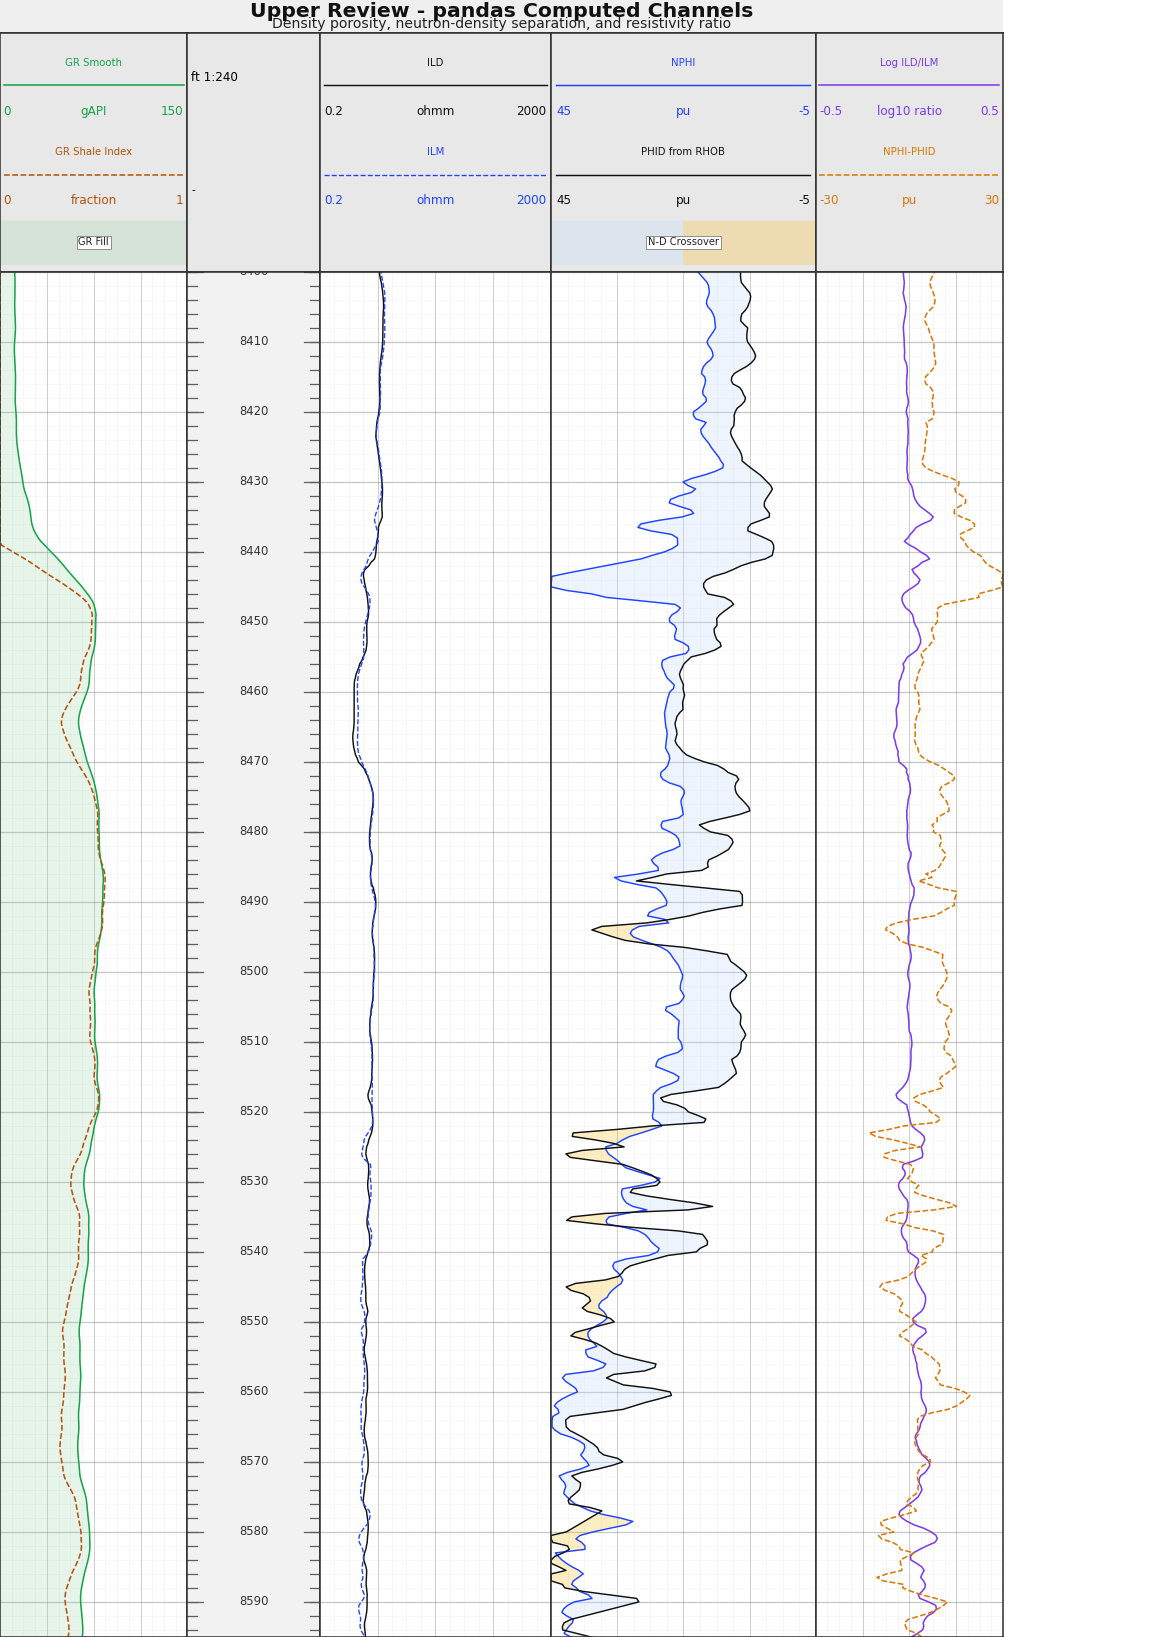

Pages created: 6
Preview page shown: 2
PDF written to: workspace/tutorials/computed_pandas/forge16b_porosity_example/renders/porosity_pandas_computed.pdf


In [5]:
from io import BytesIO

import matplotlib.pyplot as plt
from IPython.display import Image, display

from wellplot import render_report

preview_result = render_report(report)
preview_page_index = min(1, preview_result.page_count - 1)

buffer = BytesIO()
preview_result.artifact[preview_page_index].savefig(buffer, format="png", dpi=140)
preview_png = buffer.getvalue()
for figure in preview_result.artifact:
    plt.close(figure)

display(Image(data=preview_png))

pdf_result = render_report(report, output_path=pdf_path)
print("Pages created:", pdf_result.page_count)
print("Preview page shown:", preview_page_index + 1)
print("PDF written to:", pdf_result.output_path.relative_to(REPO_ROOT))

## How To Adapt This Recipe

- keep the pandas computation cell separate from the layout cell so petrophysical logic and plotting logic remain reviewable
- replace the matrix/fluid density constants with values appropriate for your reservoir
- add every derived channel to `working_dataset` before creating the report builder
- use `LogBuilder` for repeatable YAML generation instead of copying and editing YAML by hand
- remember that saved YAML does not persist in-memory computed arrays; export computed data separately if you need a standalone file-only workflow
